# Joint GTEx + AHBA Sample Tensor

Phase 3 test surface for the cross-dataset tensor view.

- **Stage 3a** (already in `eval_samples.py`): `region_matched_superset` returns the AHBA superset axis for both datasets; GTEx carries `future_imputation_mask=True` on padded unmatched parcels.
- **Stage 3b** (this notebook, below): build two `TensorView`s on the shared frame, then assemble a `JointTensorView` via `build_joint_tensor_view`.
- **Stage 3c** (this notebook, below): render the raw joint plot via `plot_joint_tensor_voxels` with per-dataset min-max scaling and a single shared colorbar.
- **Stage 3d** (next): `plot_sampled_tensor(..., dataset='combined')` convenience wrapper.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eval_samples import (
    build_sampled_tensor,
    build_joint_tensor_view,
    plot_joint_tensor_voxels,
    summarize_joint_selection,
)

set_academic_style()

In [2]:
CSV_PATH = Path('data/raw/gxp_samples.csv')
ACTIVE_GENE_LIST = 'richiardi2015'  # richiardi2015, allgenes_stable_r0.2

# Region frame: 'region_matched_superset' so both datasets share the AHBA axis
# (GTEx superset returns the AHBA axis with future_imputation_mask on padded cells).
REGION_ORDERING = 'region_matched_superset'
MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'

# Representative defaults from the split notebooks (GTEx repr: 75/100/None;
# AHBA repr: 6/100/75). Joint requires identical region/gene axes; picking the
# tighter pair (N_GENES=100, N_REGIONS=75) aligns both views on the AHBA prefix.
N_GTEX_SUBJECTS = 75
N_AHBA_SUBJECTS = 6
N_GENES = 100
N_REGIONS = 75

MIN_REGIONS_PER_SUBJECT = 5
RANDOM_SEED = 42

# Subject-axis stacking: AHBA first (lower z) so GTEx renders on top.
STACK_ORDER = ('AHBA', 'GTEx')

# Render knobs
MISSING_ALPHA = 1.0           # solid gray for unobserved AHBA cells
FUTURE_IMPUTATION_ALPHA = 0.45  # translucent gray for GTEx padded cells (visible but distinguishable)
# 'two_pass'  -> opaque cells painted first, translucent slab overlaid on top (cleaner seam)
# 'single_pass' -> original behavior; one voxel call with mixed alphas (shows the compositing artifact)
MASK_RENDER_MODE = 'two_pass'
FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0

SUBJECT_TICK_STEP = 2   # denser subject ticks
GENE_TICK_STEP = 10
REGION_TICK_STEP = 3    # region labels on, every 3rd
TICK_LABEL_PAD = -3.0

SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'

SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False

SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False

SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = True
DATASET_GAP = 5  # empty subject-axis cells inserted between datasets

## Stage 3b — Build per-dataset views on the shared AHBA superset frame

Build a GTEx `TensorView` and an AHBA `TensorView` from the same CSV with identical `gene_panel`, `random_seed`, `matching_policy`, and `region_ordering='region_matched_superset'`. After Stage 3a the GTEx superset path returns the AHBA axis with `future_imputation_mask` on the padded unmatched parcels, so the two views land on the exact same region/gene frame.

In [3]:
common_kwargs = dict(
    region_ordering=REGION_ORDERING,
    gene_panel=ACTIVE_GENE_LIST,
    n_regions=N_REGIONS,
    n_genes=N_GENES,
    min_regions_per_subject=MIN_REGIONS_PER_SUBJECT,
    random_seed=RANDOM_SEED,
    matching_policy=MATCHING_POLICY,
    matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    gtex_rep_mode=GTEX_REP_MODE,
    gtex_hemi_mode=GTEX_HEMI_MODE,
)

gtex_view = build_sampled_tensor(
    CSV_PATH,
    dataset='GTEx',
    n_subjects=N_GTEX_SUBJECTS,
    **common_kwargs,
)
ahba_view = build_sampled_tensor(
    CSV_PATH,
    dataset='AHBA',
    n_subjects=N_AHBA_SUBJECTS,
    **common_kwargs,
)

print(f'GTEx values: {gtex_view.values.shape}   region_axis_kind={gtex_view.region_axis_kind}')
print(f'AHBA values: {ahba_view.values.shape}   region_axis_kind={ahba_view.region_axis_kind}')
print(f'shared regions identical: {gtex_view.regions == ahba_view.regions}')
print(f'shared genes identical:   {gtex_view.genes   == ahba_view.genes}')
print(f'GTEx future-imputation cols: {int(gtex_view.future_imputation_mask.any(axis=0).sum())}')
print(f'AHBA future-imputation cols: {int(ahba_view.future_imputation_mask.any(axis=0).sum())}')

/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:211: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/src/eval_utils/eval_samples.py:211: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


GTEx values: (75, 75, 97)   region_axis_kind=ahba_parcel
AHBA values: (6, 75, 97)   region_axis_kind=ahba_parcel
shared regions identical: True
shared genes identical:   True
GTEx future-imputation cols: 63
AHBA future-imputation cols: 0


### Stage 3b (cont.) — Assemble the `JointTensorView`

`build_joint_tensor_view(gtex_view, ahba_view)` validates that regions, genes, and `region_axis_kind` match, concatenates subjects along axis 0, records per-dataset `dataset_slices`, and derives `matched_region_count` from the GTEx `future_imputation_mask` (the first column where any subject is padded).

In [4]:
joint_view = build_joint_tensor_view(gtex_view, ahba_view, stack_order=STACK_ORDER)

print(f'joint values: {joint_view.values.shape}  (subjects x regions x genes)')
print(f'dataset_slices: {joint_view.dataset_slices}')
print(f'matched_region_count: {joint_view.matched_region_count}')
print(f'region_axis_kind: {joint_view.region_axis_kind}')
print(f'first matched region: {joint_view.regions[0]!r}')
print(f'first unmatched region: {joint_view.regions[joint_view.matched_region_count]!r}')
print(
    f'observed cells per dataset: '
    f'GTEx={int(joint_view.observed_mask[joint_view.dataset_slices["GTEx"]].sum())}, '
    f'AHBA={int(joint_view.observed_mask[joint_view.dataset_slices["AHBA"]].sum())}'
)
print(
    f'future-imputation cells per dataset: '
    f'GTEx={int(joint_view.future_imputation_mask[joint_view.dataset_slices["GTEx"]].sum())}, '
    f'AHBA={int(joint_view.future_imputation_mask[joint_view.dataset_slices["AHBA"]].sum())}'
)

joint values: (81, 75, 97)  (subjects x regions x genes)
dataset_slices: {'AHBA': slice(0, 6, None), 'GTEx': slice(6, 81, None)}
matched_region_count: 12
region_axis_kind: ahba_parcel
first matched region: 'LH_SalVentAttn_PFCl_1'
first unmatched region: 'Cerebellar_Region1'
observed cells per dataset: GTEx=688, AHBA=392
future-imputation cells per dataset: GTEx=4725, AHBA=0


In [5]:
summarize_joint_selection(joint_view).head(20)

,subject,dataset
0,10021,AHBA
1,12876,AHBA
2,14380,AHBA
3,15496,AHBA
4,15697,AHBA
5,9861,AHBA
6,GTEX-11GSP,GTEx
7,GTEX-11O72,GTEx
8,GTEX-11ONC,GTEx
9,GTEX-11TTK,GTEx


## Stage 3c — Render the raw joint tensor

`plot_joint_tensor_voxels(joint_view, ...)` consumes only the `JointTensorView`. Per-dataset robust (2-98%) min-max scaling collapses both blocks onto a shared `[0, 1]` colormap so a single colorbar can show relative-within-dataset expression. GTEx future-imputation cells render translucent (alpha ~0.28), AHBA unobserved cells render solid gray, and `dataset_gap` leaves a 1-cell gap on the subject axis between the two blocks. `ax._joint_dataset_ranges` exposes the raw `(vmin, vmax)` used per dataset.

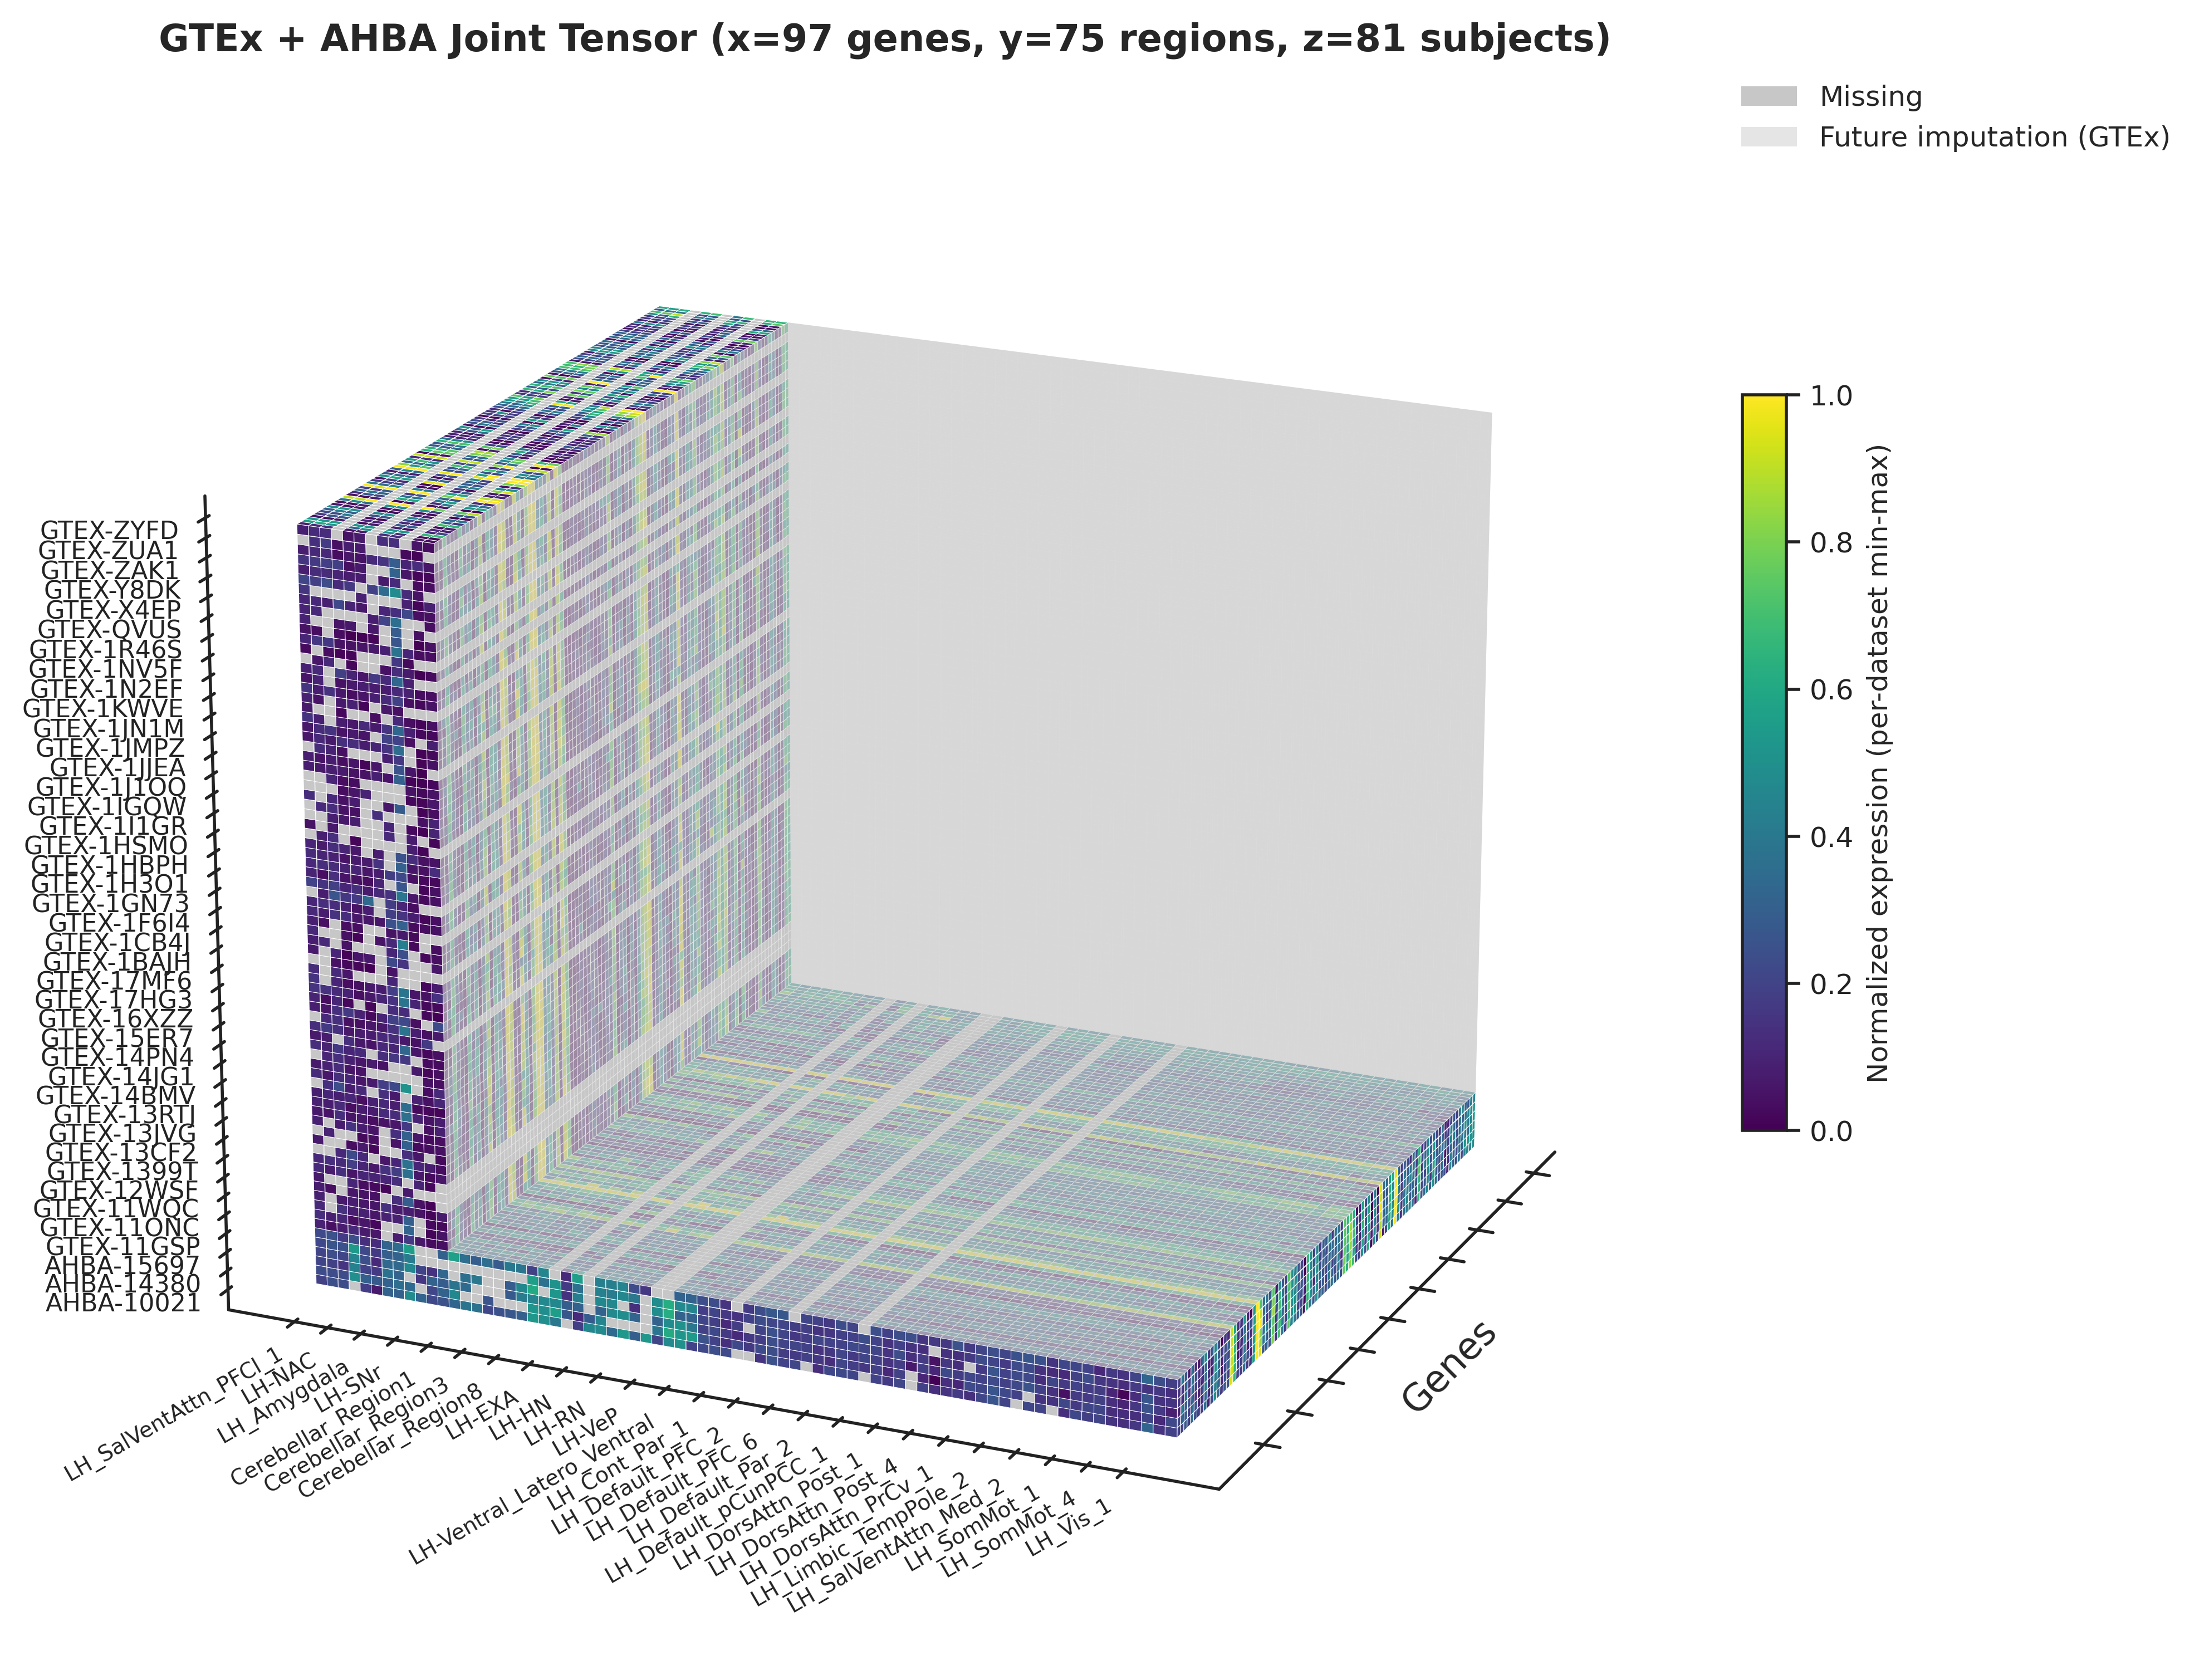

{'AHBA': (2.2163740454555683, 12.542314676601192),
 'GTEx': (0.01369164024894508, 5.446598068146903)}

In [6]:
fig, ax = plot_joint_tensor_voxels(
    joint_view,
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE,
    dpi=DPI,
    axes_bbox=AXES_BBOX,
    colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT,
    box_zoom=BOX_ZOOM,
    title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT,
    elev=ELEV,
    azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP,
    gene_tick_step=GENE_TICK_STEP,
    region_tick_step=REGION_TICK_STEP,
    tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE,
    gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL,
    show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL,
    show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES,
    show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID,
    show_legend=SHOW_LEGEND,
    dataset_gap=DATASET_GAP,
    mask_render_mode=MASK_RENDER_MODE,
)
plt.show()
ax._joint_dataset_ranges

## Next: Stage 3d

`plot_sampled_tensor(..., dataset='combined')` will wrap the build + joint + render path for one-line use. Later milestones reuse the same `JointTensorView` surface for ComBat-harmonized, strict LORO, and full-brain imputed pairs.